In [ ]:
!pip install langgraph
!pip install langchain
!pip install langsmith
!pip install langchain_groq
!pip install langchain_tavily
!pip install python-dotenv

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

In [ ]:
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

In [ ]:
from langchain_groq import ChatGroq

model = ChatGroq(model="llama-3.1-8b-instant", api_key=GROQ_API_KEY, streaming=True)

## Chatbot with Tools

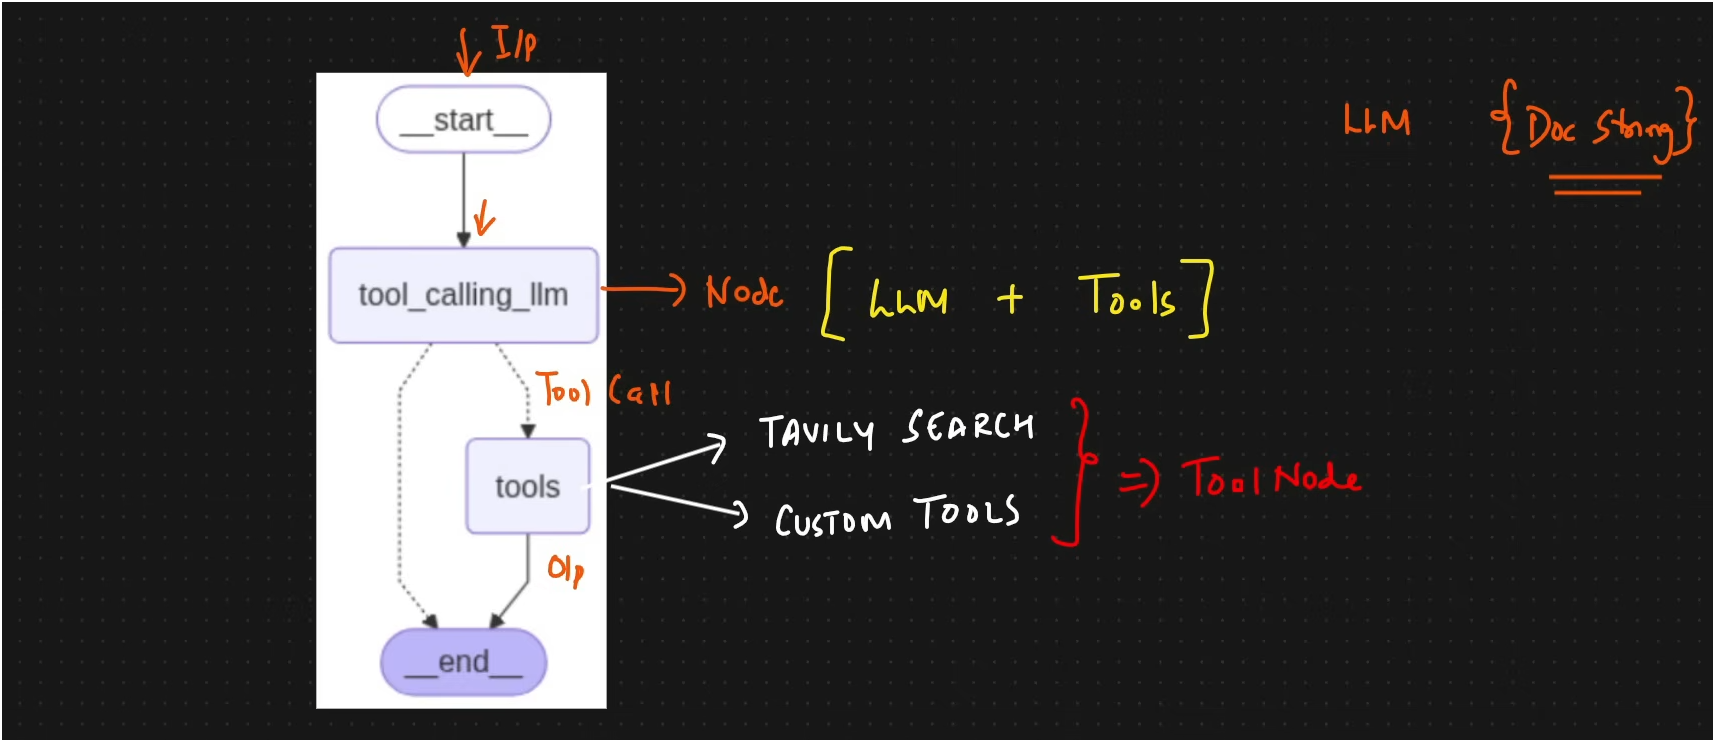

Basically we add a Tool Node which can contains multiple tools like some custom made tools also and we provide docstring in our tools to make llm identify that this tool can be used for particular queries and if some queries requires tool call it will make the tool call otherwise it will directly generate the output

Creating Tavily Tool

In [ ]:
from langchain_tavily import TavilySearch
search_tool = TavilySearch(max_results=2, tavily_api_key = TAVILY_API_KEY)



search_tool.invoke("what is Langgraph")

{'query': 'what is Langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the navigat

custom function

In [ ]:
def multiply(a:int, b:int) -> int:
  """Multiplies two integers"""
  return a*b

So here we didn't added @tool decorator from "langchain.tools" because bind_tool() function expects Tool objects not plain python functions and in langchain when we used "bind_tool()" we need to decorate it there but LangGraph ToolNode is smarter when it receives a plain python function then it automatically converts it into a Tool object thats why we are not using the decorator here, also Tool object looks like this

<pre>
Tool(
    name="get_weather",
    description="Get weather for a city",
    args_schema=...
)
</pre>

In [ ]:
tools = [search_tool, multiply]

In [ ]:
model_with_tools = model.bind_tools(tools)

Now at this point our llm know about the availaible tools as we know and we need someone who can call it so now we create our StateGraph which will call the tools and manage the workflow

1. Let's create our State

In [ ]:
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph import add_messages
class State(TypedDict):
  messages : Annotated[list, add_messages]

2. Let's create our Node functionality

In [ ]:
def ToolsLLM(state:State):
  return {"messages" : [model_with_tools.invoke(state["messages"])]}

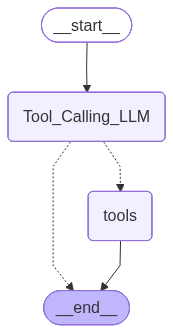

In [ ]:
from langgraph.graph import StateGraph, END, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Graph builder
graph_builder = StateGraph(State)

# Adding nodes
graph_builder.add_node("Tool_Calling_LLM", ToolsLLM)
graph_builder.add_node("tools", ToolNode(tools)) # This "tools" must be like this all lower letters otherwise it wont work
# Add Edges
graph_builder.add_edge(START, "Tool_Calling_LLM")
graph_builder.add_conditional_edges(
    "Tool_Calling_LLM",
    tools_condition
)
graph_builder.add_edge("tools", END)

# Compile
graph = graph_builder.compile()

graph


Now while creating edges above we know in our graph there are two edges coming from "Tool_Calling_LLM" and this is called condtional edges, so here we use "add_conditional_edges()" and pass first our "Tool_Calling_LLM" because edges are coming from it then the second we pass "tools_condition" we imported and there are only two simple condtions which it follow :
<pre>
1. If the last message from the assistant is a tool call -> tools_condition routes to "Tools" node

2. If the last message from the assistant is not a tool call -> tools_condition routes to END node
</pre>

One more thing here the LLM has decided all the Tool calls and then ToolNode is just executing it and providing result thats why it doesnt END after the first tool call in case of multiple tool usage in a single input string

In [ ]:
response = graph.invoke({"messages" : "What is Latest AI news"})

In [ ]:
response["messages"][-1].content


'{"query": "Latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://zamin.uz/en/technology/211220-the-ai-market-is-bifurcating-will-open-source-models-replace-anthropic.html", "title": "The AI Market is Bifurcating: Will Open Source Models Replace Anthropic? - Zamin.uz", "score": 0.67140645, "published_date": "Tue, 07 Jul 2026 20:28:06 GMT", "content": "## Comments0\\n\\n…\\n\\n## Related news\\n\\nAustralia\'s Largest Startup Competition: Application Deadline Extended for Startup BattlefieldToday, 03:50Meta introduces Muse, a new AI image generatorToday, 03:29Microsoft shifts to its own models to reduce AI costsToday, 00:53Discord unfairly bans thousands of users due to AI errorToday, 00:29Google announces launch date for new Pixel 11 smartphonesYesterday, 23:59Figma expands its capabilities: Bud startup team acquiredYesterday, 23:53\\n\\nAnnouncementsPartnership", "raw_content": null}, {"url": "https://www.businessinsider.com/openai-so

In [ ]:
for m in response["messages"]:
  m.pretty_print()

================================ Human Message =================================

What is Latest AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (vsa28e3kr)
 Call ID: vsa28e3kr
  Args:
    query: Latest AI news
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "Latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://zamin.uz/en/technology/211220-the-ai-market-is-bifurcating-will-open-source-models-replace-anthropic.html", "title": "The AI Market is Bifurcating: Will Open Source Models Replace Anthropic? - Zamin.uz", "score": 0.67140645, "published_date": "Tue, 07 Jul 2026 20:28:06 GMT", "content": "## Comments0\n\n…\n\n## Related news\n\nAustralia's Largest Startup Competition: Application Deadline Extended for Startup BattlefieldToday, 03:50Meta 

In [ ]:
response = graph.invoke({"messages" : "What is 2 multiplied by 5"})

In [ ]:
response["messages"][-1].content

'10'

In [ ]:
for m in response["messages"]:
  m.pretty_print()

================================ Human Message =================================

What is 2 multiplied by 5
================================== Ai Message ==================================
Tool Calls:
  multiply (29egyxent)
 Call ID: 29egyxent
  Args:
    a: 2
    b: 5
================================= Tool Message =================================
Name: multiply

10


Now lets try something interesting

In [ ]:
response = graph.invoke({"messages" : "What is 2 multiplied by 5 then multiplied by 3"})

In [ ]:
response["messages"][-1].content

'30'

In [ ]:
for m in response["messages"]:
  m.pretty_print()

================================ Human Message =================================

What is 2 multiplied by 5 then multiplied by 3
================================== Ai Message ==================================
Tool Calls:
  multiply (yhest4a31)
 Call ID: yhest4a31
  Args:
    a: 2
    b: 5
  multiply (bzyt2q8nn)
 Call ID: bzyt2q8nn
  Args:
    a: 10
    b: 3
================================= Tool Message =================================
Name: multiply

10
================================= Tool Message =================================
Name: multiply

30


Now lets try both together

In [ ]:
response = graph.invoke({"messages" : "Give me the recent AI news and then tell me What is 2 multiplied by 5"})

In [ ]:
response["messages"][-1].content

'10'

In [ ]:
for m in response["messages"]:
  m.pretty_print()

================================ Human Message =================================

Give me the recent AI news and then tell me What is 2 multiplied by 5
================================== Ai Message ==================================
Tool Calls:
  tavily_search (j81tbw5ma)
 Call ID: j81tbw5ma
  Args:
    query: recent AI news
    time_range: day
    topic: news
  multiply (t276czdt3)
 Call ID: t276czdt3
  Args:
    a: 2
    b: 5
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://letsdatascience.com/news/tum-debuts-soft-robotic-glove-restoring-hand-grasp-a2382408", "title": "TUM debuts soft robotic glove restoring hand grasp - Let's Data Science", "score": 0.6994397, "published_date": "Tue, 07 Jul 2026 14:29:46 GMT", "content": "dpl=dpl\\_C172j12UNM3eQs895KoCgVVnUJLA\",\"precedence\":\"next\",\"crossOrigin\":\"$undefined\",

Now here we are getting this Tools message as in our graph its making the tool calls and then the Tool message is displaying the output

----------------------------------

## The idea of ReAct agent

But what here if we instead of going to END after a Tool Call we go back again to the LLM, then the LLM will be the ultimate decision maker and this type of setup is called ReAct agent and this is what "create_agent()" in langchain creates

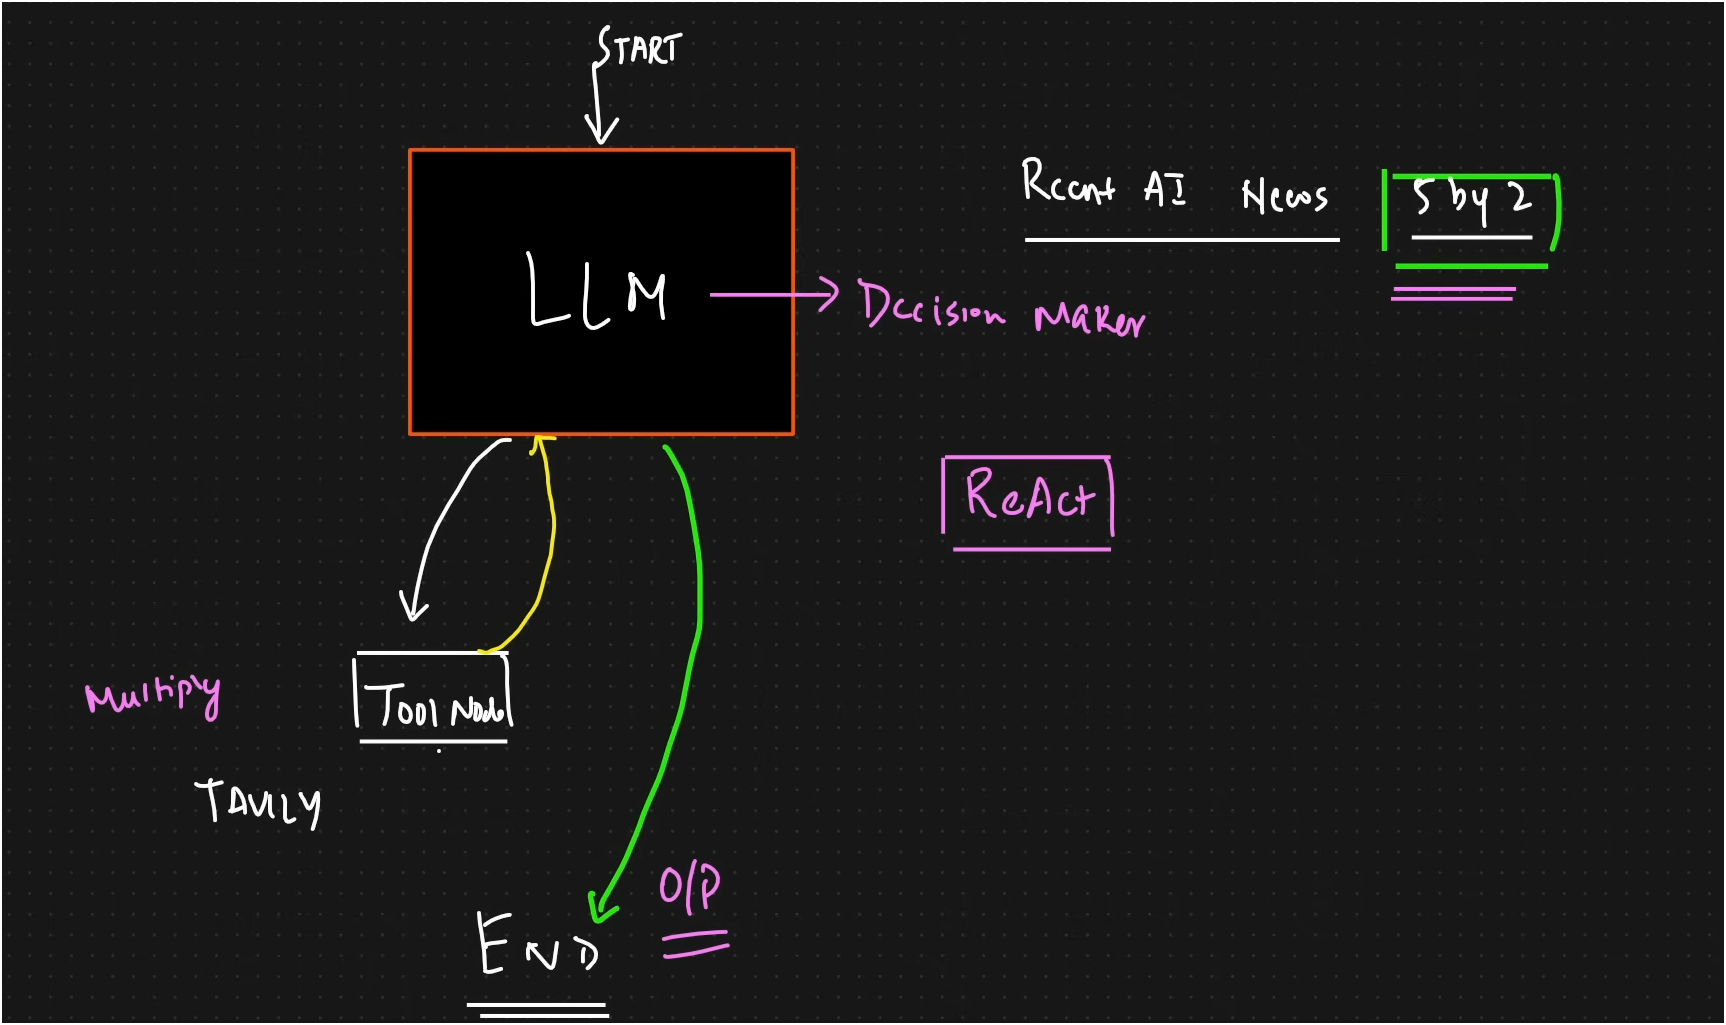

We have to understand one thing here about dependent and independent queries


Quesries can be independent like our above example "Tell me latest AI news then multiply 5 by 2", this is a independent query both the tool calls are independent, So in this case the LLM will decide to call both the tools together and ToolNode will execute them and return the Tool result back to LLM for the ultimate output


Queries can also be depedent like "Tell me latest AI news then summarize the first article", now here the second query of summarization depends on the first LLM does not know what to summarize so the LLM will only make first tool call to get Latest AI news then the ToolNode execute and return back the result to LLM now LLM see there is another tool call needed (suppose a tool exist which do summarization better) to the summarization tool then it again make a tool call and ToolNode execute and return back to LLM and then it generate the output


So the point here is that execution of tools can be together or in a sequential manner and it is decided by the LLM not ToolNode.

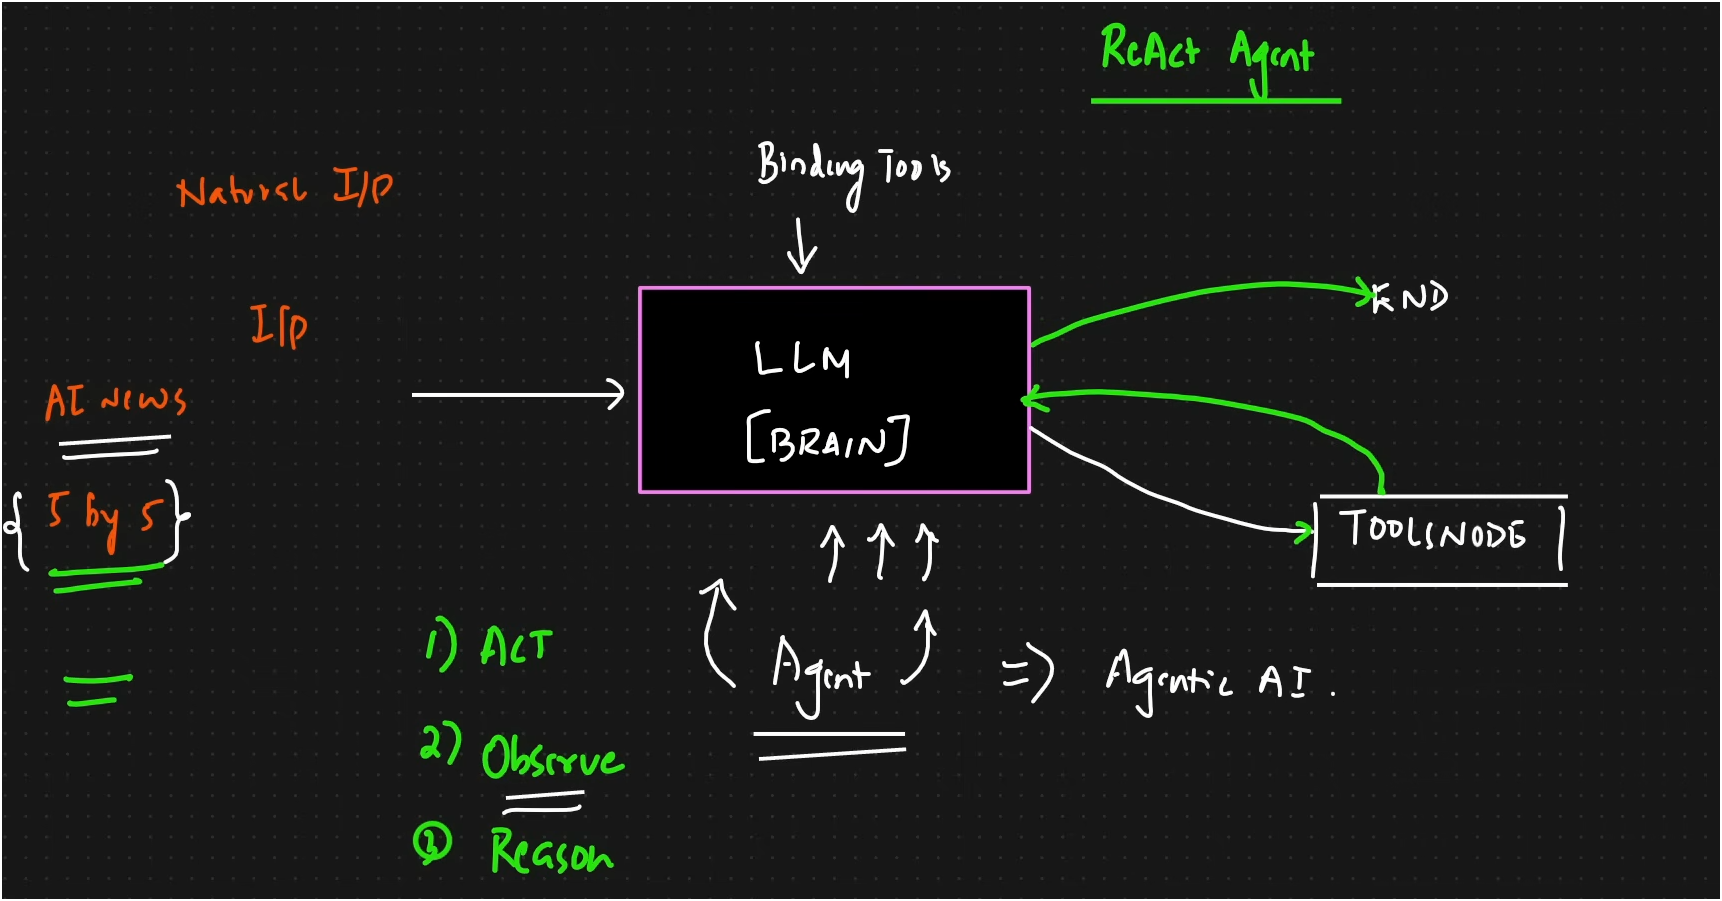

A ReAct agent consists of 3 things.

1. ACT - means whenever an input comes the LLM will be able to make a tool call
2. Observe - Observe after receiving the tool result or context, whether further anything needed or not.
3. Reason - It means after it get the output from the tool what it needs to do, the LLM is making the decision



And this is where the Agent behavious comes into existence

<b><u>Now lets implement this architecture of ReAct Agent</b></u>

We will use the same Architecture above we used for learning with a slight change

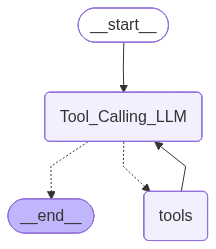

In [ ]:
# This is what create_agent() internally do in Langchain
from langgraph.graph import StateGraph, END, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Graph builder
graph_builder = StateGraph(State)

# Adding nodes
graph_builder.add_node("Tool_Calling_LLM", ToolsLLM)
graph_builder.add_node("tools", ToolNode(tools)) # This "tools" must be like this all lower letters otherwise it wont work
# Add Edges
graph_builder.add_edge(START, "Tool_Calling_LLM")
graph_builder.add_conditional_edges(
    "Tool_Calling_LLM",
    tools_condition
)
graph_builder.add_edge("tools", "Tool_Calling_LLM") # This is the change we just change the edge of ToolNode towards our LLM

# Compile
graph = graph_builder.compile()

graph

Now see how good the output will be

In [ ]:
response = graph.invoke({"messages" : "What is Latest AI news and 5 multiplied by 2"})

In [ ]:
print(response["messages"][-1].content)

The latest AI news is about researchers building a soft pneumatic glove that restores intentional grasping in a patient with severe hand paralysis, using a surface-EMG predictor with 97% sensitivity in a Nature Machine Intelligence study published June 23, 2026.

The result of multiplying 5 by 2 is 10.
